# Importing Libraries
- NumPy and Pandas are used for numerical operations and data manipulation.
- Matplotlib and Seaborn are used for visualization.
- sklearn provides tools for machine learning, including stacking classifiers, model selection, and evaluation metrics.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Load the Data
- The Breast Cancer dataset contains data on different features of cell nuclei present in a breast mass.
- The target variable indicates whether the mass is benign (0) or malignant (1).

- Load the dataset

In [ ]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Data overview
print("DataFrame Head:")
print(df.head())
print("\nDataFrame Info:")
print(df.info())
print("\nDataFrame Description:")
print(df.describe())

DataFrame Head:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  

- Features:
        - The dataset contains 30 features, such as mean radius, mean texture, mean perimeter, and mean area of cell nuclei.
- Target:
        - target (0 for benign, 1 for malignant)

# Data Visualization
- Before building the model, we will explore the data to understand the distributions of features and the target variable.

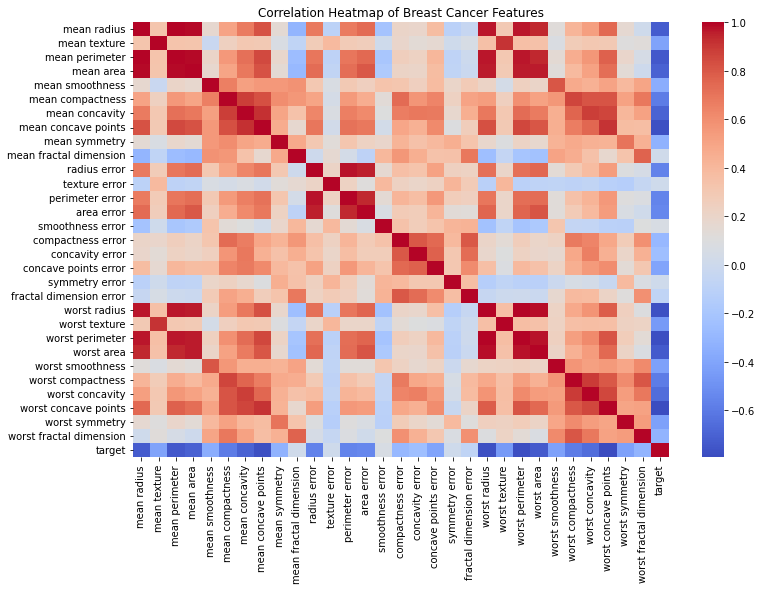

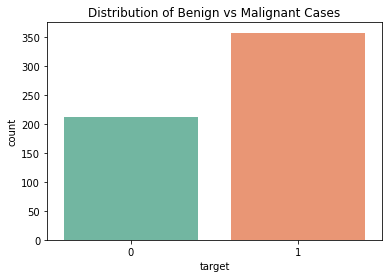

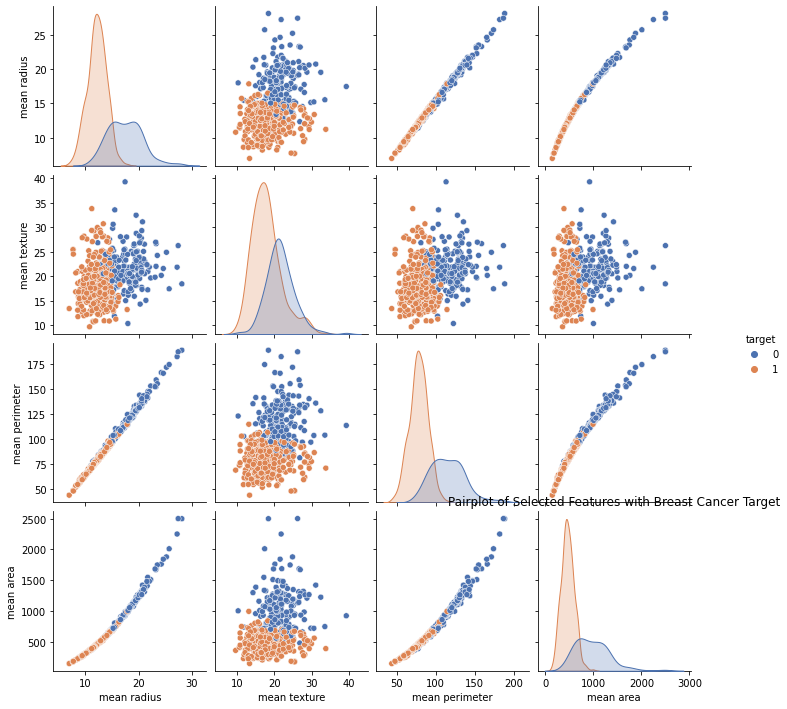

In [ ]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap of Breast Cancer Features')
plt.show()

# Distribution of target variable
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Distribution of Benign vs Malignant Cases')
plt.show()

# Pairplot for selected features
sns.pairplot(df[['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'target']], hue='target', palette='deep')
plt.title('Pairplot of Selected Features with Breast Cancer Target')
plt.show()

# Split the Data
- The train_test_split function splits the dataset into training (80%) and testing (20%) subsets, ensuring that our model can be evaluated on unseen data.

- Features and target

In [ ]:
X = df.drop(columns='target')
y = df['target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Stacking Classifier Model
- Stacking is an ensemble method that combines multiple models to improve accuracy.
- We'll use Gradient Boosting, Random Forest, and Support Vector Machine as base models, and Logistic Regression as the meta-model.

In [ ]:
# Base models

estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('dt', DecisionTreeClassifier()),
    ('svc', SVC(kernel='linear', probability=True, random_state=42))]

# Meta-model
stacking_clf = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())

## Train the Stacking Classifier

In [ ]:
stacking_clf.fit(X_train, y_train)

StackingClassifier(estimators=[('rf', RandomForestClassifier(random_state=42)),
                               ('dt', DecisionTreeClassifier()),
                               ('svc',
                                SVC(kernel='linear', probability=True,
                                    random_state=42))],
                   final_estimator=LogisticRegression())

# Make Predictions & Evaluate the Mode
- The predict method generates predictions for the test data based on the trained stacking model.

In [ ]:
y_train_pred = stacking_clf.predict(X_train)
y_test_pred = stacking_clf.predict(X_test)

# Evaluate the model on training data
print("Confusion Matrix: Train Data")
print(confusion_matrix(y_train, y_train_pred))
print("\nClassification Report (Train Data):")
print(classification_report(y_train, y_train_pred))
print("============================================================================")

# Evaluate the model on test data
print("Confusion Matrix: Test Data")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report (Test Data):")
print(classification_report(y_test, y_test_pred))

Confusion Matrix: Train Data
[[168   1]
 [  0 286]]

Classification Report (Train Data):
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       169
           1       1.00      1.00      1.00       286

    accuracy                           1.00       455
   macro avg       1.00      1.00      1.00       455
weighted avg       1.00      1.00      1.00       455

Confusion Matrix: Test Data
[[40  3]
 [ 0 71]]

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        43
           1       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

